## Exploratory Data Analysis и линейная регрессия

<strong style="color: red">Внимание!</strong> В этом ноутбуке используется библиотека `ipyleaflet`. Чтобы ее установить так, чтобы она работала, нужно совершить 2 простых шага:

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
# %%bash
# pip3 install ipyleaflet
# jupyter nbextension enable --py --sys-prefix ipyleaflet

После этого перезапустите сессию (не `Restart Kernel`, а нажмите `Ctrl+C` в терминале, где вы запускали ноутбук, и запустите заново). Лучше это сделать сразу, чтобы потом не пришлось прерывать сессию и терять промежуточные результаты работы. Если все сделано правильно, вы должны увидеть карту Москвы, выполнив ячейку ниже:

In [2]:
# !pip install ipyleaflet

In [3]:
# !jupyter nbextension enable --py --sys-prefix ipyleaflet

In [4]:
from ipyleaflet import Map, basemaps
Map(center=(55.7522200, 37.6155600), zoom=10, basemap=basemaps.Esri.NatGeoWorldMap)

Map(center=[55.75222, 37.61556], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_theme(style="darkgrid")

## Часть 0.

**Задание 1.**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [6]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data = pd.read_csv("train.csv")
data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [7]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data.drop(columns='dropoff_datetime', inplace=True)
data.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [8]:
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458644 non-null  object        
 1   vendor_id           1458644 non-null  int64         
 2   pickup_datetime     1458644 non-null  datetime64[ns]
 3   passenger_count     1458644 non-null  int64         
 4   pickup_longitude    1458644 non-null  float64       
 5   pickup_latitude     1458644 non-null  float64       
 6   dropoff_longitude   1458644 non-null  float64       
 7   dropoff_latitude    1458644 non-null  float64       
 8   store_and_fwd_flag  1458644 non-null  object        
 9   trip_duration       1458644 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 111.3+ MB


В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Разбейте выборку на обучающую и тестовую в отношении 7:3.

In [9]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data, data['trip_duration'], test_size=0.3, random_state=42)

Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

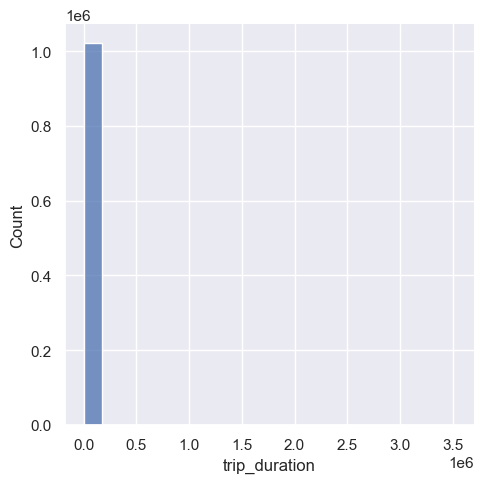

In [10]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
sns.displot(y_train, bins=20)

**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений? 

> Есть выбросы

В соревновании в качестве метрики качества использовалось RMSLE:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Вопрос**: Как вы думаете, почему авторы соревнования выбрали именно RMSLE, а не RMSE?

> Важное отличие RMLSE от RMSE: RMSLE имеет значение относительной ошибки, а RMSE абсолютной. В RMLSE масштаб ошибки не будет так сильно влиять на результат. Например, если длительность поездки составляет больше 30 минут, то RMLSE не будет так реагировать на ошибку в 1 минуту и в 2 минуты (тут эти ошибки можно считать равными), по сравнению с RMSE, где такая ошибка будет штрафоваться намного сильнее.

Давайте проделаем следующий трюк: будем предсказывать не целевую переменную, а ее *логарифм*. Обозначим $\hat{y}_i = \log{(y_i + 1)}$ — модифицированный таргет, а $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, то есть логарифм таргета. Чтобы предсказать исходное значение, мы можем просто взять экспоненту от нашего предсказания: $a(x_i) = \exp(\hat{a}(x_i)) - 1$.

**Вопрос**: Покажите, что оптимизация RMSLE для модели $a$ эквивалентна оптимизации MSE для модели $\hat{a}$.

**Доказательство**: ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
$a(x_i) = \exp(\hat{a}(x_i)) - 1$ = $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, $\hat{y}_i = \log{(y_i + 1)}$"\\ = $\log{(\exp({a}(x_i)) - 1 + 1)} = {a}(x_i)$

Аналогично для $\hat{a}(x_i)$:

$\hat{a}(x_i) = \exp({a}(x_i)) - 1 = \log{(\exp(\hat{a}(x_i)) - 1 + 1)} = \hat{a}(x_i)$


У логарифмирования таргета есть еще одно полезное свойство. Чтобы его увидеть, добавьте к нашим выборкам колонки `log_trip_duration` (воспользуйтесь `np.log1p`) и нарисуйте гистограмму модифицированного таргета по обучающей выборке:

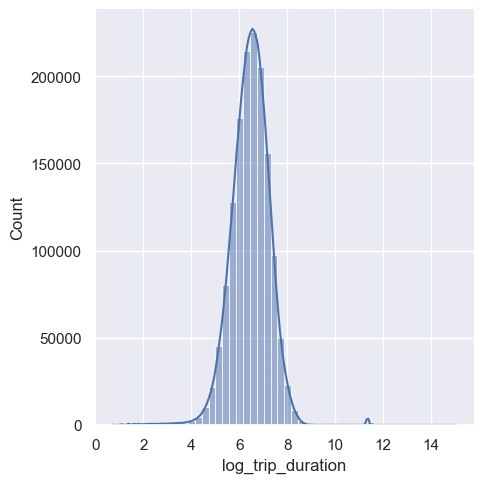

In [11]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['log_trip_duration'] = np.log1p(data['trip_duration'].values)
sns.displot(data['log_trip_duration'], kde=True, bins=50)

## Часть 1. Изучаем `pickup_datetime`

**Задание 2.**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году (например, можно воспользоваться `sns.countplot`):

<Axes: ylabel='count'>

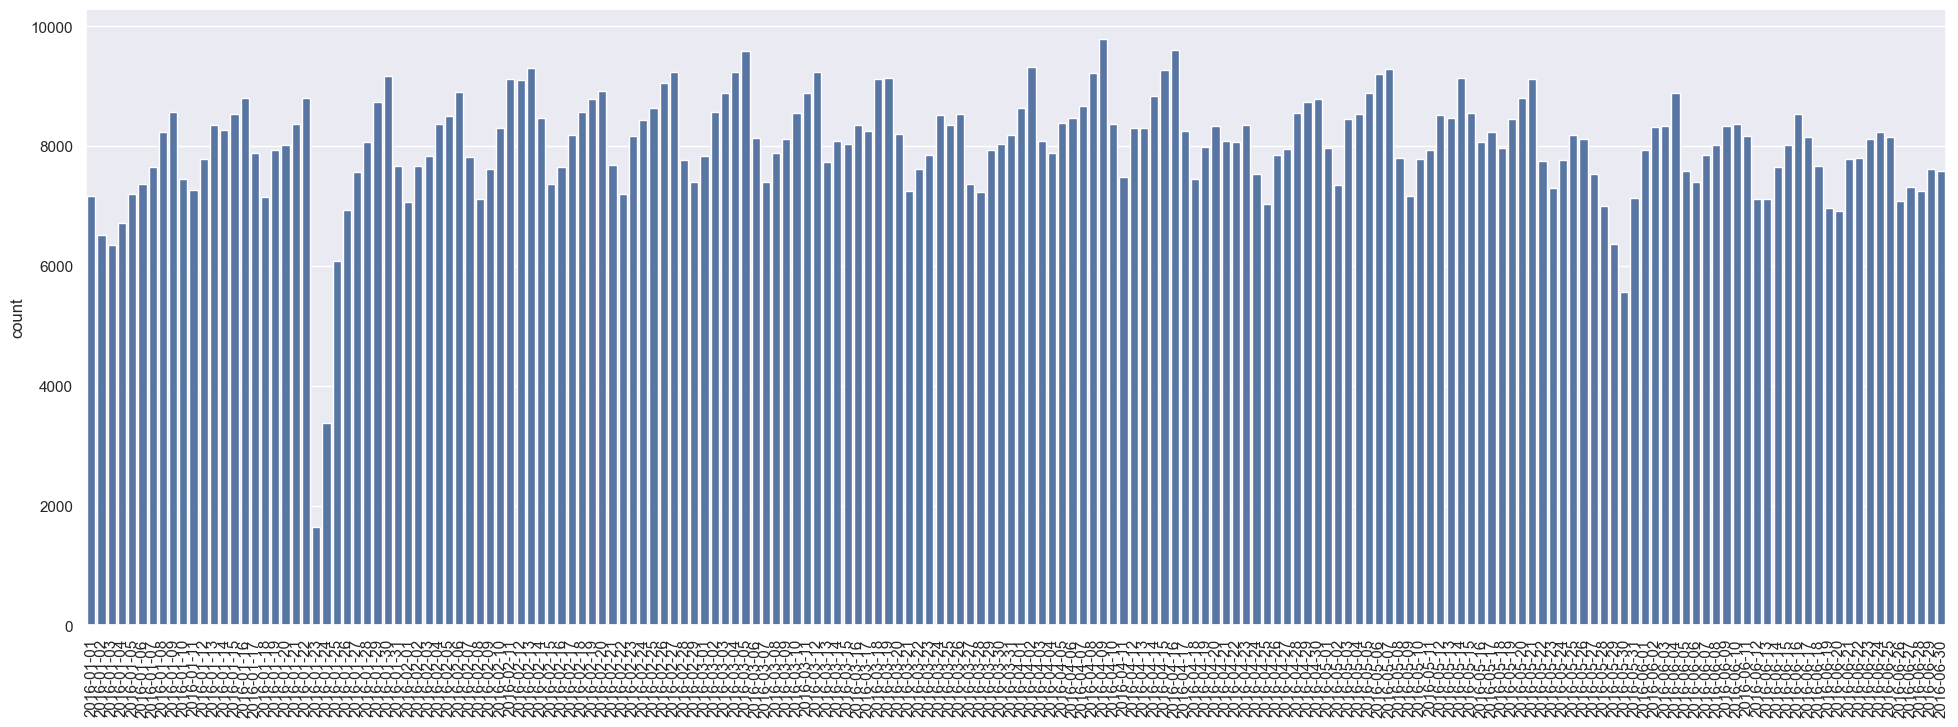

In [12]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
plt.figure(figsize=(24,8))
plt.xticks(rotation = 90)
data1 = data['pickup_datetime'].dt.date
sns.countplot(x=sorted(data1))

**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

https://ria.ru/20160123/1364032228.html Запретили ездить из-за снежной бури

Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках (воспользуйтесь `sns.relplot`):

In [13]:
data['pickup_datetime'].dt.date.value_counts()[-2:]


pickup_datetime
2016-01-24    3383
2016-01-23    1648
Name: count, dtype: int64

Text(0.5, 1.0, 'зависимости количества поездок от дня недели')

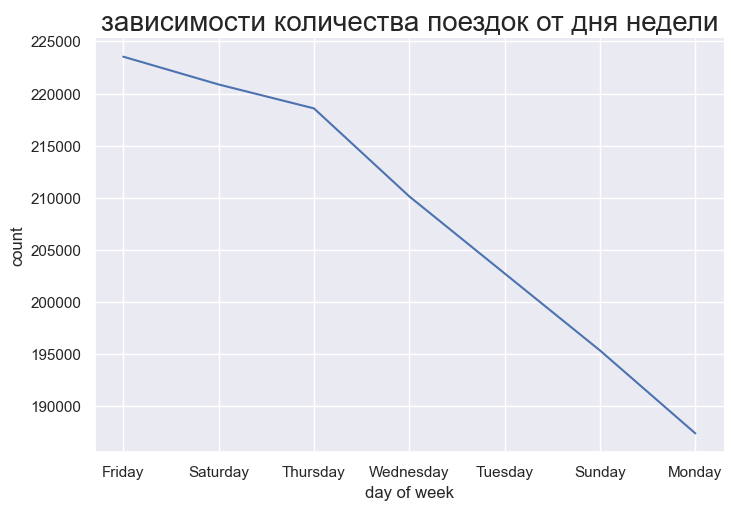

In [14]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x = data['pickup_datetime'].dt.day_name().value_counts().index
y = data['pickup_datetime'].dt.day_name().value_counts()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('day of week')
plt.ylabel('count')
plt.title('зависимости количества поездок от дня недели', fontsize=20)

Text(0.5, 1.0, 'зависимости количества поездок от часов в сутках')

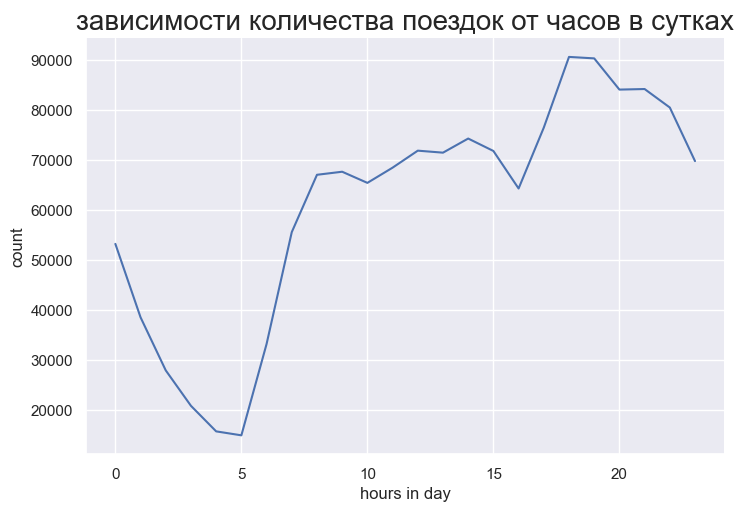

In [15]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x = data['pickup_datetime'].dt.hour.value_counts().index
y = data['pickup_datetime'].dt.hour.value_counts()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('hours in day')
plt.ylabel('count')
plt.title('зависимости количества поездок от часов в сутках', fontsize=20)

**Задание 3.**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, воспользуйтесь `hue` в `sns.relplot`). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

Text(0.5, 1.0, 'dependence')

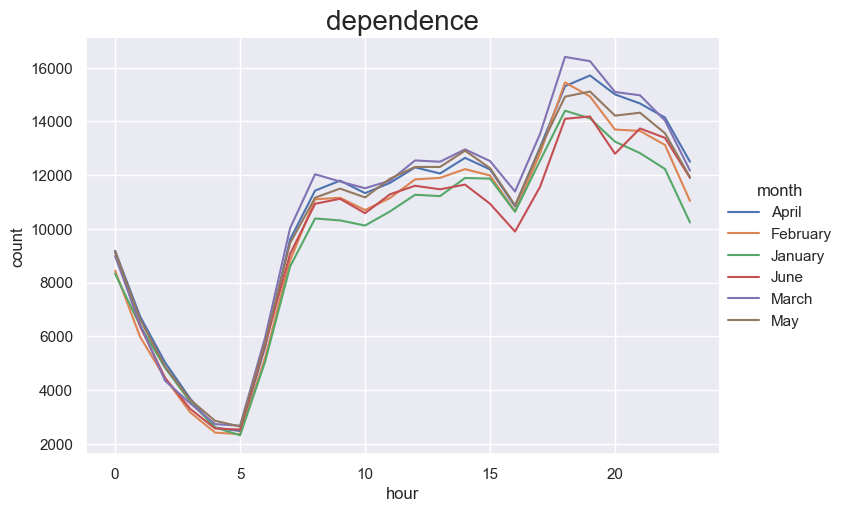

In [16]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['hour'] = data['pickup_datetime'].dt.hour
data['month'] = data['pickup_datetime'].dt.month_name()
data['day_of_week'] = data['pickup_datetime'].dt.day_name()
data['day_of_year'] = data['pickup_datetime'].dt.day_of_year

tmp = pd.DataFrame(data[['month','hour', 'day_of_week']])

sns.relplot(hue = 'month', x = 'hour', y = 'day_of_week', data = tmp.groupby(['month', 'hour']).count(), kind = 'line', aspect=1.5)

plt.xlabel('hour')
plt.ylabel('count')
plt.title('dependence', fontsize=20)

Text(0.5, 1.0, 'dependence')

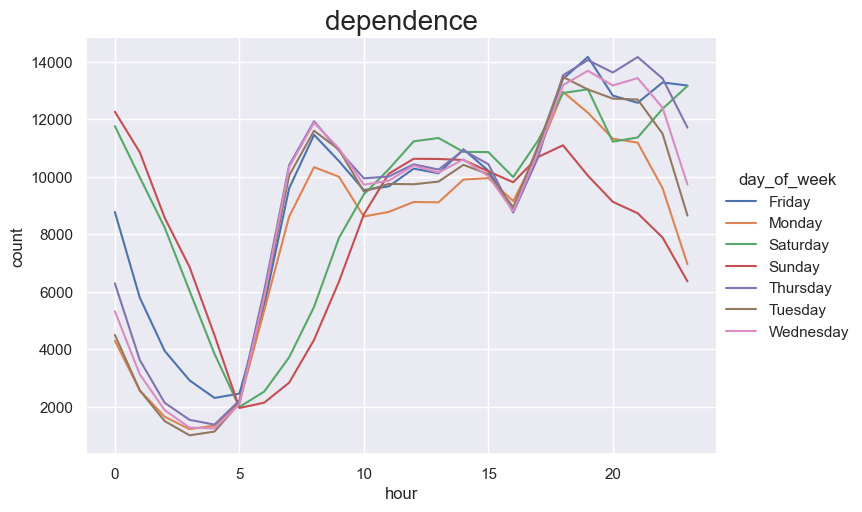

In [17]:
sns.relplot(hue = 'day_of_week', x = 'hour', y = 'month', data = tmp.groupby(['day_of_week', 'hour']).count(), kind = 'line', aspect=1.5)

plt.xlabel('hour')
plt.ylabel('count')
plt.title('dependence', fontsize=20)

**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

Месяца практичестки не отличаются, дни недели имеют небольшие отличия. По субботам и воскресеньям люди просыпаются позже. Также в будние дни возрастает количество поездок после 5 утра и после 4 вечера

**Задание 4.**. По *обучающей выборке* нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

Text(0.5, 1.0, 'dependence')

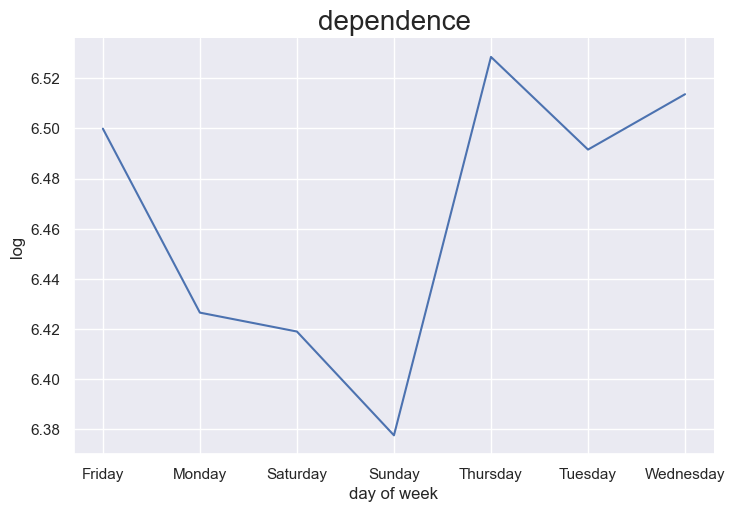

In [18]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x = data.groupby('day_of_week')['log_trip_duration'].mean().index
y = data.groupby('day_of_week')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('day of week')
plt.ylabel('log')
plt.title('dependence', fontsize=20)

Text(0.5, 1.0, 'dependence')

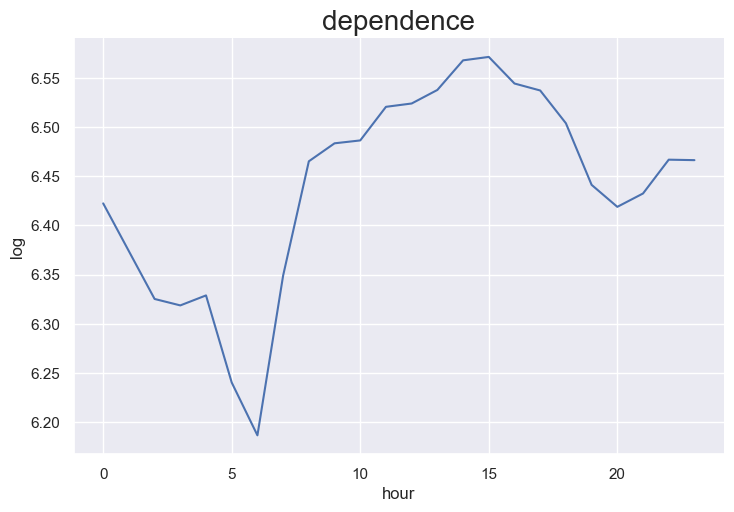

In [19]:
x = data.groupby('hour')['log_trip_duration'].mean().index
y = data.groupby('hour')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('hour')
plt.ylabel('log')
plt.title('dependence', fontsize=20)

Text(0.5, 1.0, 'dependence')

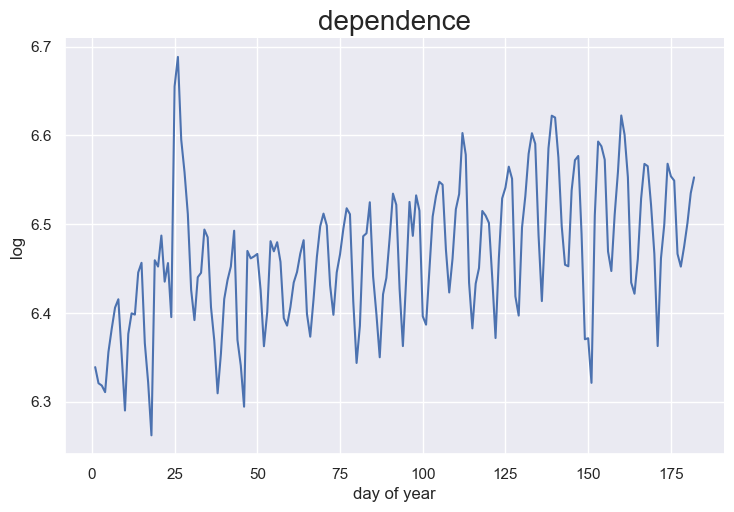

In [20]:
x = data.groupby('day_of_year')['log_trip_duration'].mean().index
y = data.groupby('day_of_year')['log_trip_duration'].mean()

sns.relplot(x = x, y = y, aspect=1.5, kind='line')

plt.xlabel('day of year')
plt.ylabel('log')
plt.title('dependence', fontsize=20)

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

In [21]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

data['is_an_anomaly'] = 0
data.loc[data['pickup_datetime'].dt.date.isin(data['pickup_datetime'].dt.date.value_counts()[-2:].index),'is_an_anomaly'] = 1
data[data['is_an_anomaly'] == 1]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,hour,month,day_of_week,day_of_year,is_an_anomaly
310,id1027675,2,2016-01-23 08:46:42,1,-73.969536,40.755219,-73.976524,40.747948,N,1197,7.088409,8,January,Saturday,23,1
481,id3105640,1,2016-01-24 20:35:19,1,-73.977982,40.684780,-73.954132,40.613346,N,1537,7.338238,20,January,Sunday,24,1
593,id2657420,1,2016-01-23 00:06:25,1,-73.982101,40.745903,-73.993843,40.683250,N,1290,7.163172,0,January,Saturday,23,1
794,id3382236,2,2016-01-23 10:38:43,5,-73.975281,40.760990,-73.963181,40.767761,N,332,5.808142,10,January,Saturday,23,1
850,id2386155,2,2016-01-24 12:42:54,1,-73.983528,40.738029,-73.983238,40.737949,N,686,6.532334,12,January,Sunday,24,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456780,id2525361,2,2016-01-24 10:09:34,1,-73.966812,40.793770,-73.976181,40.786449,N,602,6.401917,10,January,Sunday,24,1
1456874,id2600978,1,2016-01-23 00:47:43,2,-73.992233,40.725750,-73.957001,40.766415,N,910,6.814543,0,January,Saturday,23,1
1457000,id3470639,1,2016-01-24 13:10:56,1,-73.984879,40.759155,-73.994270,40.754189,N,551,6.313548,13,January,Sunday,24,1
1457224,id3905294,1,2016-01-23 02:57:21,1,-73.924911,40.810028,-73.914009,40.818890,N,403,6.001415,2,January,Saturday,23,1


Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков стоит рассматривать как категориальные, а какие - как численные? Почему?

> категориальные - month, is_an_anomaly, 
> 
> числовые - day_of_year, log_trip_duration,hour

**Задание 5.**. Обучите `Ridge`-регрессию с параметрами по умолчанию, закодировав все категориальные признаки с помощью `OneHotEncoder`. Численные признаки отмасштабируйте с помощью `StandardScaler`. Используйте только признаки, которые мы выделили в этой части задания.

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Предполагаем, что данные уже загружены и признаки добавлены (hour, month, day_of_week, day_of_year, is_an_anomaly, log_trip_duration)
# Если их нет, добавь как в предыдущих ячейках ноутбука
x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Убедимся, что hour — категориальный (преобразуем в строку для OneHotEncoder)
x_train['hour'] = x_train['hour'].astype(str)
x_test['hour'] = x_test['hour'].astype(str)

# Определяем признаки и таргет
features = ['hour', 'month', 'day_of_week', 'day_of_year', 'is_an_anomaly']
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year']
categorical_features = ['hour', 'month', 'day_of_week', 'is_an_anomaly']

# Создаем препроцессор: масштабирование для числовых, one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

# Создаем пайплайн: препроцессинг + Ridge-регрессия (дефолтные параметры: alpha=1.0)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")

MSE на тестовой выборке: 0.6213456137255474
RMSLE на тестовой выборке: 0.7882547898525878


## Часть 2. Изучаем координаты
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Подготовлена функция, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

In [23]:
from ipyleaflet import Map, Circle, LayerGroup, basemaps

In [24]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    
    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    center = (data[latitude_column].mean(), data[longitude_column].mean())
    result_map = Map(center=center, zoom=10, basemap=basemaps.Esri.NatGeoWorldMap)

    circles = []
    for _, row in data.iterrows():
        circles.append(Circle(
            location=(row[latitude_column], row[longitude_column]),
            fill_color=color,
            fill_opacity=0.2,
            radius=300,
            stroke=False
        ))
    circles_layer = LayerGroup(layers=circles)
    result_map.add_layer(circles_layer)

    return result_map

In [25]:
show_circles_on_map(data.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

Map(center=[np.float64(40.75183375167847), np.float64(-73.9744069519043)], controls=(ZoomControl(options=['pos…

In [26]:
show_circles_on_map(data.sample(1000), "dropoff_latitude", "dropoff_longitude", "blue")

Map(center=[np.float64(40.75212615585327), np.float64(-73.97270609283447)], controls=(ZoomControl(options=['po…

**Вопрос**: Какие две точки выделяются на карте?
> аэропорт кэнеди и лу гуардия

**Задание 6.**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [27]:
import numpy as np

def haversine_array(lat1, lon1, lat2, lon2):
    """
    Векторизованная функция Haversine.
    Возвращает расстояние в км между двумя наборами точек.
    """
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    AVG_EARTH_RADIUS = 6371.0  # км

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return AVG_EARTH_RADIUS * c

data['haversine'] = haversine_array(
    data['pickup_latitude'].values,
    data['pickup_longitude'].values,
    data['dropoff_latitude'].values,
    data['dropoff_longitude'].values
)


Так как мы предсказываем логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку:

In [28]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['log_haversine'] = np.log1p(data['haversine'])
data[['haversine', 'log_haversine', 'log_trip_duration']]

,haversine,log_haversine,log_trip_duration
0,1.498521,0.915699,6.122493
1,1.805507,1.031584,6.498282
2,6.385098,1.999464,7.661527
3,1.485498,0.910473,6.063785
4,1.188588,0.783257,6.077642
...,...,...,...
1458639,1.225080,0.799793,6.658011
1458640,6.049836,1.953004,6.486161
1458641,7.824606,2.177544,6.639876
1458642,1.092564,0.738390,5.924256


Убедимся, что логарифм расстояния лучше коррелирует с нашим таргетом, чем просто расстояние:

In [29]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data[['haversine', 'log_haversine', 'log_trip_duration', 'trip_duration']].corr()

,haversine,log_haversine,log_trip_duration,trip_duration
haversine,1.000000,0.844501,0.573595,0.094777
log_haversine,0.844501,1.000000,0.749882,0.102519
log_trip_duration,0.573595,0.749882,1.000000,0.253521
trip_duration,0.094777,0.102519,0.253521,1.000000


**Задание 7.** Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

<Axes: xlabel='speed', ylabel='Count'>

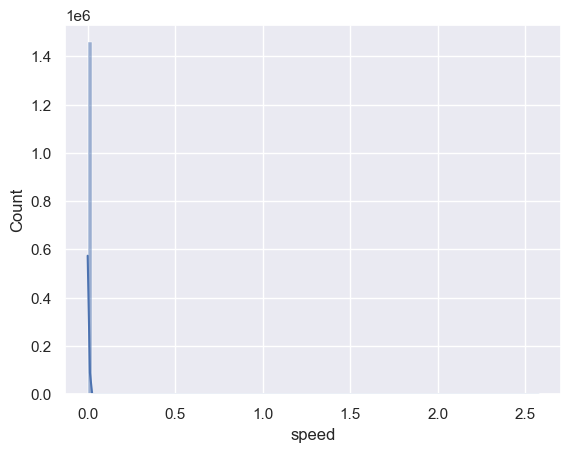

In [30]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['speed'] = data['haversine'] / data['trip_duration']

# Нарисуем гистограмму распределения скорости
sns.histplot(data['speed'], bins=100, kde=True)

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

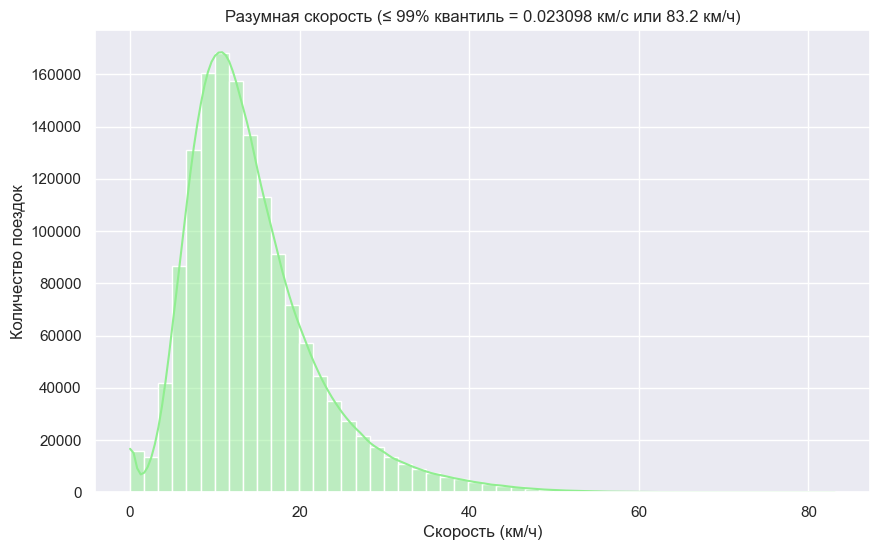

99% квантиль: 0.023098 км/с (~83.2 км/ч)
Удалено: 219 поездок


In [31]:
# print("выбор квантиляы для определения разумной скорости:")
# for q in np.arange(0.995, 1.0, 0.00001):
#     val = data['speed'].quantile(q)
#     if 60 < val*3600 < 100:
#         print(f"{q*100:5.5f}% квантиль: {val:.10f} км/с → {val*3600:.1f} км/ч")

quantile = data['speed'].quantile(0.99985)
reasonable_speed = data[data['speed'] <= quantile]

plt.figure(figsize=(10, 6))
sns.histplot(reasonable_speed['speed']*3600, bins=50, kde=True, color='lightgreen')
plt.title(f'Разумная скорость (≤ 99% квантиль = {quantile:.6f} км/с или {quantile*3600:.1f} км/ч)')
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.show()

print(f"99% квантиль: {quantile:.6f} км/с (~{quantile*3600:.1f} км/ч)")
print(f"Удалено: {len(data) - len(reasonable_speed)} поездок")

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте с помощью `sns.heatmap` график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

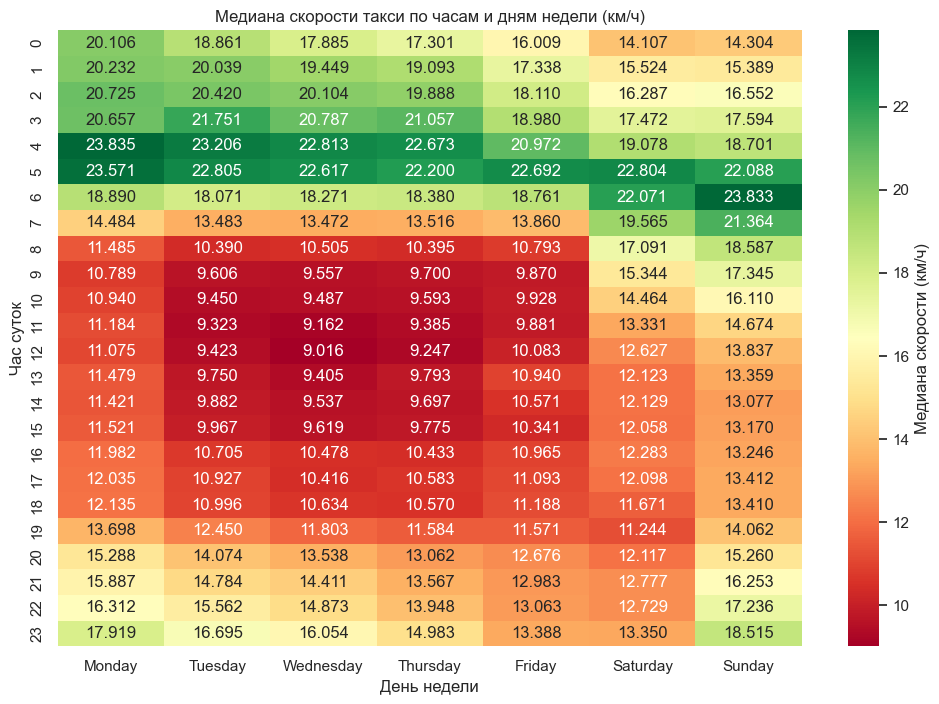

In [32]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
# === 4. Heatmap: медиана скорости (км/с) по часам и дням недели ===
median_speed_pivot = data.groupby(['hour', 'day_of_week'])['speed'].median().unstack()
# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
median_speed_pivot = median_speed_pivot[day_order]
# Переводим в км/ч для читаемости на графике (но оставляем в км/с в данных)
median_speed_kmh = median_speed_pivot * 3600

plt.figure(figsize=(12, 8))
sns.heatmap(
    median_speed_kmh,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Медиана скорости (км/ч)'}
)
plt.title('Медиана скорости такси по часам и дням недели (км/ч)')
plt.xlabel('День недели')
plt.ylabel('Час суток')
plt.show()

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

>Потому что через скорость мы сразу можем получить таргет, а значит нет смысла в обучении модели.

In [33]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data.drop('speed', inplace = True, axis=1)

**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [34]:
data['traffic_jam'] = np.where(
    # Будни: 8–19
    ((data['day_of_week'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])) &
     (data['hour'].between(8, 19))) |
    # Выходные: 11–19
    ((data['day_of_week'].isin(['Saturday', 'Sunday'])) &
     (data['hour'].between(11, 19))),
    1, 0
)

data['clear_road'] = 1- data['traffic_jam']
data[['traffic_jam', 'clear_road']]

,traffic_jam,clear_road
0,1,0
1,0,1
2,1,0
3,1,0
4,1,0
...,...,...
1458639,1,0
1458640,0,1
1458641,0,1
1458642,1,0


**Задание 8.** Как уже было замечено выше, на карте выделяются две точки - аэропорты La Guardia и John F Kennedy. Для каждого из аэропортов добавьте в выборки два признака: началась ли поездка из этого аэропорта и закончилась ли поездка в этом аэропорте.

In [35]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
# Координаты аэропорта La Guardia
la_guardia_coordinates = {'longitude': -73.8733, 'latitude': 40.7744}
# Координаты аэропорта John F Kennedy
jfk_coordinates = {'longitude': -73.7781, 'latitude': 40.6413}

# Радиус окружности вокруг аэропортов
radius = 0.01

# Добавляем признаки для La Guardia
data['pickup_from_laguardia'] = np.where(
    (data['pickup_longitude'] - la_guardia_coordinates['longitude'])**2 +
    (data['pickup_latitude'] - la_guardia_coordinates['latitude'])**2 <= radius**2, 1, 0
)
data['dropoff_to_laguardia'] = np.where(
    (data['dropoff_longitude'] - la_guardia_coordinates['longitude'])**2 +
    (data['dropoff_latitude'] - la_guardia_coordinates['latitude'])**2 <= radius**2, 1, 0
)

# Добавляем признаки для John F Kennedy
data['pickup_from_jfk'] = np.where(
    (data['pickup_longitude'] - jfk_coordinates['longitude'])**2 +
    (data['pickup_latitude'] - jfk_coordinates['latitude'])**2 <= radius**2, 1, 0
)
data['dropoff_to_jfk'] = np.where(
    (data['dropoff_longitude'] - jfk_coordinates['longitude'])**2 +
    (data['dropoff_latitude'] - jfk_coordinates['latitude'])**2 <= radius**2, 1, 0
)


Для каждого из созданных признаков нарисуйте "ящик с усами" (`sns.boxplot`) распределения логарифма времени поездки

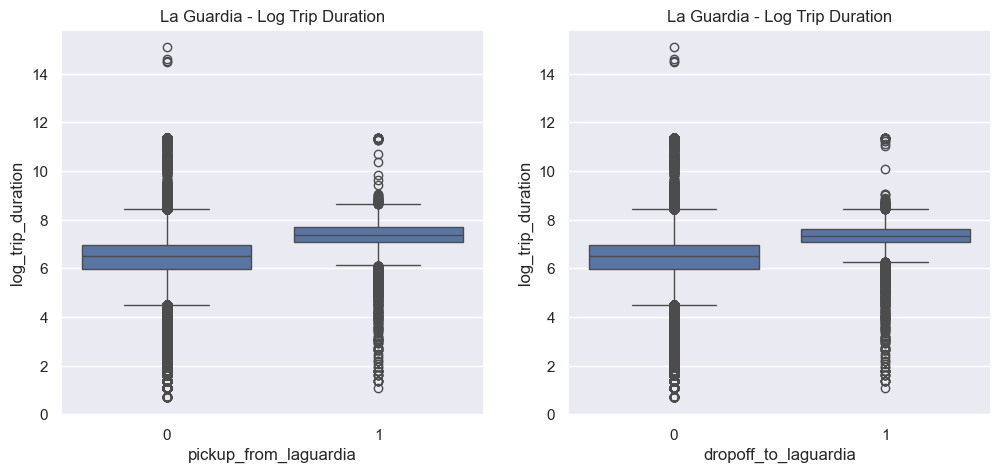

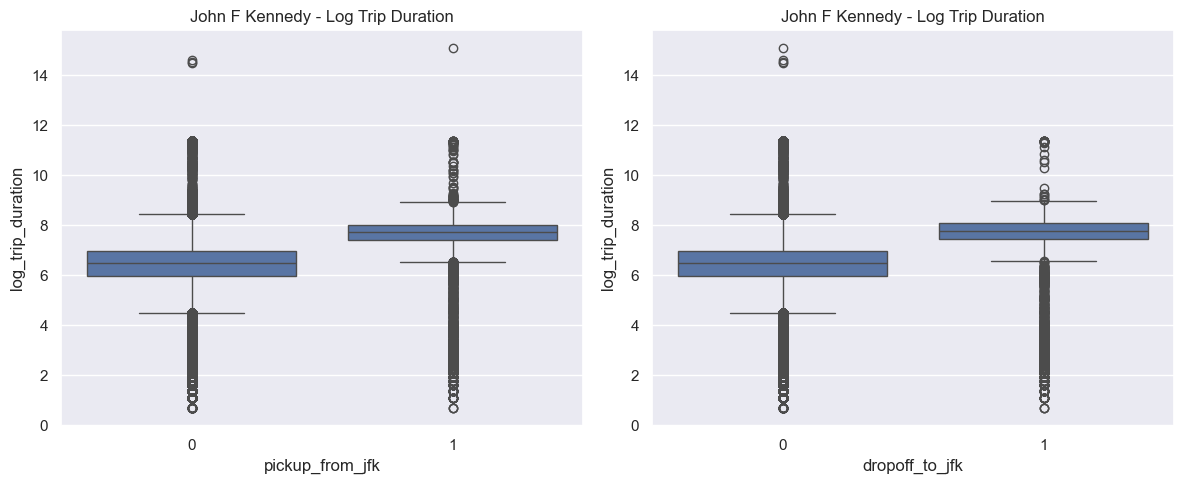

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Предполагается, что у вас есть столбец 'log_trip_duration' в датафрейме

# Признаки для La Guardia
laguardia_features = ['pickup_from_laguardia', 'dropoff_to_laguardia']
# Признаки для John F Kennedy
jfk_features = ['pickup_from_jfk', 'dropoff_to_jfk']

# Распределение логарифма времени поездки для La Guardia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='pickup_from_laguardia', y='log_trip_duration')
plt.title('La Guardia - Log Trip Duration')

plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='dropoff_to_laguardia', y='log_trip_duration')
plt.title('La Guardia - Log Trip Duration')

# Распределение логарифма времени поездки для John F Kennedy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='pickup_from_jfk', y='log_trip_duration')
plt.title('John F Kennedy - Log Trip Duration')

plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='dropoff_to_jfk', y='log_trip_duration')
plt.title('John F Kennedy - Log Trip Duration')

plt.tight_layout()
plt.show()


**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 9.** Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

In [37]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class MapGridTransformer(BaseEstimator, TransformerMixin):
    """
    Разбивает карту на ячейки и кодирует pickup/dropoff как номер ячейки.
    Точки вне области → -1.
    """
    def __init__(self, n_rows=10, n_cols=10):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.min_lat = None
        self.max_lat = None
        self.min_lon = None
        self.max_lon = None
        self.lat_step = None
        self.lon_step = None

    def fit(self, X, y=None):
        """
        Определяем границы области по обучающей выборке.
        Используем 1% и 99% квантили, чтобы убрать выбросы.
        """
        pickup_lat = X['pickup_latitude']
        pickup_lon = X['pickup_longitude']
        dropoff_lat = X['dropoff_latitude']
        dropoff_lon = X['dropoff_longitude']

        # Объединяем все координаты
        all_lat = pd.concat([pickup_lat, dropoff_lat])
        all_lon = pd.concat([pickup_lon, dropoff_lon])

        # Границы: 1% и 99% квантили
        self.min_lat = all_lat.quantile(0.01)
        self.max_lat = all_lat.quantile(0.99)
        self.min_lon = all_lon.quantile(0.01)
        self.max_lon = all_lon.quantile(0.99)

        # Шаги
        self.lat_step = (self.max_lat - self.min_lat) / self.n_rows
        self.lon_step = (self.max_lon - self.min_lon) / self.n_cols

        return self

    def transform(self, X):
        """
        Создаём два признака: pickup_grid, dropoff_grid
        """
        X = X.copy()  # не меняем исходный

        # Функция для кодирования одной точки
        def encode_point(lat, lon):
            if not (self.min_lat <= lat <= self.max_lat and self.min_lon <= lon <= self.max_lon):
                return -1
            row = int((lat - self.min_lat) // self.lat_step)
            col = int((lon - self.min_lon) // self.lon_step)
            # Защита от выхода за границы
            row = min(row, self.n_rows - 1)
            col = min(col, self.n_cols - 1)
            return row * self.n_cols + col

        # Векторизуем
        encode = np.vectorize(encode_point)

        X['pickup_grid'] = encode(X['pickup_latitude'], X['pickup_longitude'])
        X['dropoff_grid'] = encode(X['dropoff_latitude'], X['dropoff_longitude'])

        return X

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

In [38]:
grid_transformer = MapGridTransformer(n_rows=6, n_cols=8)

data = grid_transformer.fit_transform(data)

# Проверяем
print(data[['pickup_grid', 'dropoff_grid']].head())
pd.set_option('display.max_columns', None)

data

   pickup_grid  dropoff_grid
0           33            33
1           25            16
2           33            16
3           16            16
4           41            33


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,hour,month,day_of_week,day_of_year,is_an_anomaly,haversine,log_haversine,traffic_jam,clear_road,pickup_from_laguardia,dropoff_to_laguardia,pickup_from_jfk,dropoff_to_jfk,pickup_grid,dropoff_grid
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,6.122493,17,March,Monday,74,0,1.498521,0.915699,1,0,0,0,0,0,33,33
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,6.498282,0,June,Sunday,164,0,1.805507,1.031584,0,1,0,0,0,0,25,16
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,7.661527,11,January,Tuesday,19,0,6.385098,1.999464,1,0,0,0,0,0,33,16
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,6.063785,19,April,Wednesday,97,0,1.485498,0.910473,1,0,0,0,0,0,16,16
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,6.077642,13,March,Saturday,86,0,1.188588,0.783257,1,0,0,0,0,0,41,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,6.658011,13,April,Friday,99,0,1.225080,0.799793,1,0,0,0,0,0,25,24
1458640,id1049543,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,6.486161,7,January,Sunday,10,0,6.049836,1.953004,0,1,0,0,0,0,24,41
1458641,id2304944,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6.639876,6,April,Friday,113,0,7.824606,2.177544,0,1,0,0,0,0,33,16
1458642,id2714485,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,5.924256,15,January,Tuesday,5,0,1.092564,0.738390,1,0,0,0,0,0,25,25


**Задание 10.** Обучите `Ridge`-регрессию со стандартными параметрами на признаках, которые мы выделили к текущему моменту. Категориальные признаки закодируйте через one-hot-кодирование, численные признаки отмасштабируйте.

In [39]:
# Предполагаем, что данные уже загружены и признаки добавлены (hour, month, day_of_week, day_of_year, is_an_anomaly, log_trip_duration)
# Если их нет, добавь как в предыдущих ячейках ноутбука
x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Определяем признаки и таргет
features = ['hour',	'month', 'day_of_week', 'day_of_year',	'is_an_anomaly',	'haversine',	'log_haversine',	'traffic_jam',	'clear_road',	'pickup_from_laguardia',	'dropoff_to_laguardia',	'pickup_from_jfk',	'dropoff_to_jfk',	'pickup_grid',	'dropoff_grid']
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year', 'haversine',	'log_haversine']
categorical_features = [f for f in features if f not in numeric_features]

# Создаем препроцессор: масштабирование для числовых, one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")

MSE на тестовой выборке: 0.22408289320730385
RMSLE на тестовой выборке: 0.47337394648132447


## Часть 3. Изучаем оставшиеся признаки

**Задание 11.** У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

In [40]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
print('count of unique values:')
print('vendor_id:', data['vendor_id'].unique().shape[0])
print('passenger_count:', data['passenger_count'].unique().shape[0])
print('store_and_fwd_flag:', data['store_and_fwd_flag'].unique().shape[0])

count of unique values:
vendor_id: 2
passenger_count: 10
store_and_fwd_flag: 2


Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

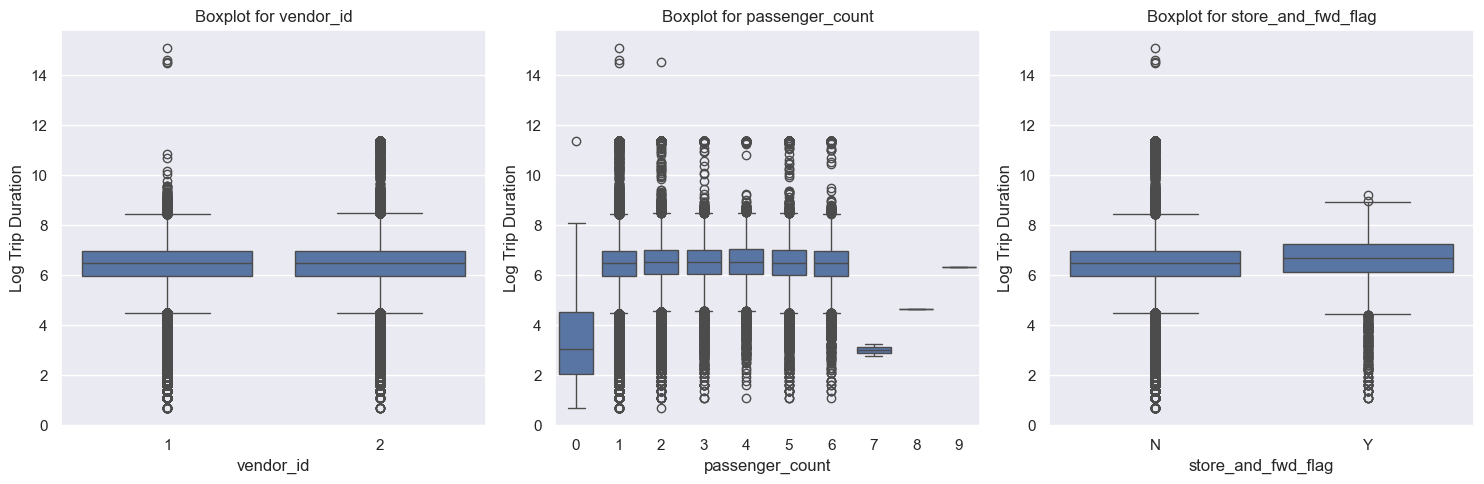

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Признаки для анализа
features_to_analyze = ['vendor_id', 'passenger_count', 'store_and_fwd_flag']


# Создаем подграфики для каждого признака
fig, axes = plt.subplots(nrows=1, ncols=len(features_to_analyze), figsize=(15, 5))

# Строим ящики с усами для каждого признака
for i, feature in enumerate(features_to_analyze):
    sns.boxplot(x=feature, y='log_trip_duration', data=data, ax=axes[i])
    axes[i].set_title(f'Boxplot for {feature}')
    axes[i].set_ylabel('Log Trip Duration')

plt.tight_layout()
plt.show()


Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [42]:
# Переводим vendor_id в {0, 1}
data['vendor_id'] = data['vendor_id'].map({1 : '0', 2 : '1'})

# Переводим store_and_fwd_flag в {0, 1}
data['store_and_fwd_flag'] = data['store_and_fwd_flag'].map({'N': '0', 'Y': '1'})
data

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,log_trip_duration,hour,month,day_of_week,day_of_year,is_an_anomaly,haversine,log_haversine,traffic_jam,clear_road,pickup_from_laguardia,dropoff_to_laguardia,pickup_from_jfk,dropoff_to_jfk,pickup_grid,dropoff_grid
0,id2875421,1,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,0,455,6.122493,17,March,Monday,74,0,1.498521,0.915699,1,0,0,0,0,0,33,33
1,id2377394,0,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,0,663,6.498282,0,June,Sunday,164,0,1.805507,1.031584,0,1,0,0,0,0,25,16
2,id3858529,1,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,7.661527,11,January,Tuesday,19,0,6.385098,1.999464,1,0,0,0,0,0,33,16
3,id3504673,1,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,0,429,6.063785,19,April,Wednesday,97,0,1.485498,0.910473,1,0,0,0,0,0,16,16
4,id2181028,1,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,0,435,6.077642,13,March,Saturday,86,0,1.188588,0.783257,1,0,0,0,0,0,41,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,1,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,0,778,6.658011,13,April,Friday,99,0,1.225080,0.799793,1,0,0,0,0,0,25,24
1458640,id1049543,0,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,0,655,6.486161,7,January,Sunday,10,0,6.049836,1.953004,0,1,0,0,0,0,24,41
1458641,id2304944,1,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,0,764,6.639876,6,April,Friday,113,0,7.824606,2.177544,0,1,0,0,0,0,33,16
1458642,id2714485,0,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,0,373,5.924256,15,January,Tuesday,5,0,1.092564,0.738390,1,0,0,0,0,0,25,25


**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

> только количество пассажиров может как то помочь (когда машина едет к заказчику видимо то длительность поездки меньше), да и то не сильно.

**Задание 12.** Проверьте свои предположения, обучив модель в том числе и на этих трех признаках. Обучайте `Ridge`-регрессию со стандартными параметрами. Категориальные признаки закодируйте one-hot-кодированием, а численные отмасштабируйте.

In [43]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Определяем признаки и таргет
features = ['hour',	'month', 'day_of_week', 'day_of_year', 'is_an_anomaly', 'haversine', 
            'log_haversine', 'traffic_jam',	'clear_road',	'pickup_from_laguardia', 'dropoff_to_laguardia', 
            'pickup_from_jfk',	'dropoff_to_jfk',	'pickup_grid',	'dropoff_grid',
            'vendor_id', 'passenger_count', 'store_and_fwd_flag']
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year', 'haversine',	'log_haversine', 'passenger_count']
categorical_features = [f for f in features if f not in numeric_features]

# Создаем препроцессор: масштабирование для числовых, one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")


MSE на тестовой выборке: 0.22388972015590972
RMSLE на тестовой выборке: 0.4731698639557571


Cтарые значения:
1. MSE на тестовой выборке: 0.22408289320730385
2. RMSLE на тестовой выборке: 0.47337394648132447

>изменения минимальны

Если признаки не дали какого-то ощутимого улучшения метрики, их можно выбросить из данных.

In [44]:
data = data.drop(['vendor_id', 'store_and_fwd_flag', 'passenger_count'], axis=1)

## Часть 4. Улучшаем модель

**Задание 13.** В наших данных есть нетипичные объекты: с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите обучающую выборку от них.

In [45]:
# # data['trip_duration'].sort_values()
# oldData['trip_duration'].sort_values()


In [46]:
# oldData = data.copy()

99% квантиль пройденного расстояния: 7.630836 км
99% квантиль времени поездки: 87.000000 s


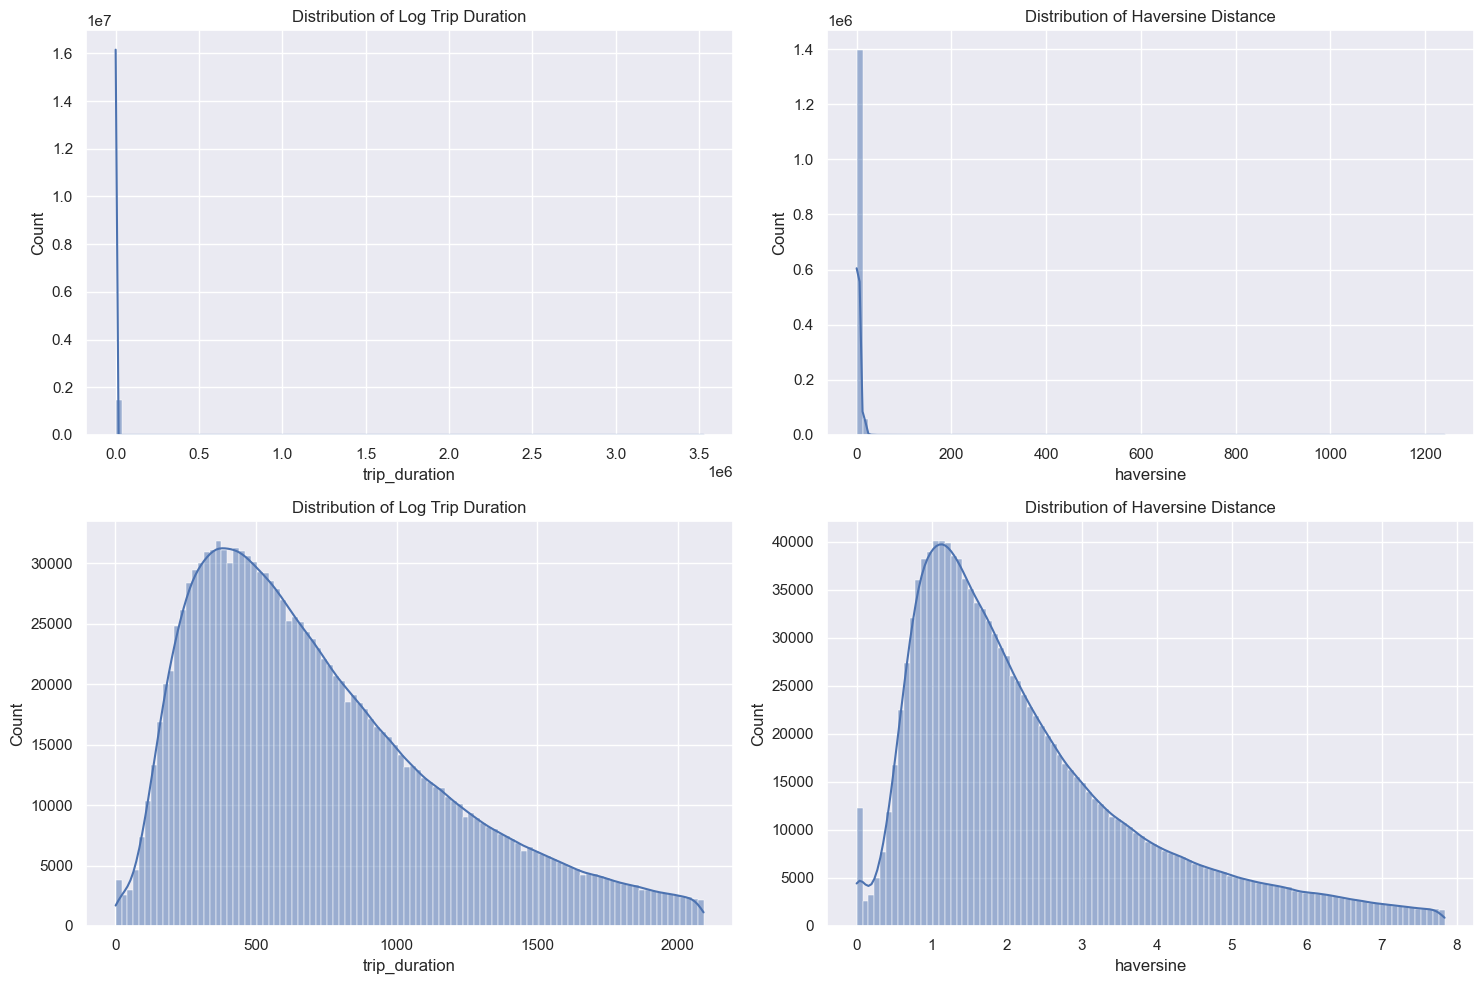

In [47]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import seaborn as sns
import matplotlib.pyplot as plt
# data = oldData.copy()
# Визуализация времени поездки
plt.figure(figsize=(15, 10))

q25trip = data['trip_duration'].quantile(0.25)
q75trip = data['trip_duration'].quantile(0.75)
q25hav = data['haversine'].quantile(0.25)
q75hav = data['haversine'].quantile(0.75)

tripMin = q25trip - 1.5*(q75trip-q25trip)
tripMax = q75trip + 1.5*(q75trip-q25trip)
havMin = q25hav - 1.5*(q75hav-q25hav)
havMax = q75hav + 1.5*(q75hav-q25hav)

plt.subplot(2, 2, 1)
sns.histplot(data['trip_duration'], bins=100, kde=True)
plt.title('Distribution of Log Trip Duration')

# Визуализация пройденного расстояния
plt.subplot(2, 2, 2)
sns.histplot(data['haversine'], bins=100, kde=True)
plt.title('Distribution of Haversine Distance')

quantile = data['haversine'].quantile(0.90)
print(f"99% квантиль пройденного расстояния: {quantile:.6f} км")
quantile = data['trip_duration'].quantile(0.01)
print(f"99% квантиль времени поездки: {quantile:.6f} s")
data = data[(tripMin < data['trip_duration']) & (data['trip_duration'] < tripMax)]
plt.subplot(2, 2, 3)
sns.histplot(data['trip_duration'], bins=100, kde=True)
plt.title('Distribution of Log Trip Duration')
data = data[(havMin < data['haversine']) & (data['haversine'] < havMax)]

# Визуализация пройденного расстояния
plt.subplot(2, 2, 4)
sns.histplot(data['haversine'], bins=100, kde=True)
plt.title('Distribution of Haversine Distance')

plt.tight_layout()
plt.show()



Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Попробуйте объединить редкие категории в одну. Естественно, делать это нужно только для действительно редких категорий.

In [48]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
data['airport'] = data[['pickup_from_laguardia', 'dropoff_to_laguardia', 'pickup_from_jfk', 'dropoff_to_jfk']].max(axis=1)
data = data.drop(columns=['is_an_anomaly', 'pickup_from_laguardia', 'dropoff_to_laguardia', 'pickup_from_jfk', 'dropoff_to_jfk', 'clear_road'])


In [49]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Определяем признаки и таргет
features = ['hour',	'month', 'day_of_week', 'day_of_year', 'haversine', 
            'log_haversine', 'traffic_jam',	'airport',	'pickup_grid',	'dropoff_grid']
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year', 'haversine',	'log_haversine']
categorical_features = [f for f in features if f not in numeric_features]
print(f"До OneHot-кодирования: {X_train.shape[1]} признаков")

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_features])
n_ohe_features = ohe.transform(X_train[categorical_features]).shape[1]

total_after = len(numeric_features) + n_ohe_features
print(f"После OneHot-кодирования: {total_after} признаков")
print(f"  → числовые: {len(numeric_features)}")
print(f"  → one-hot: {n_ohe_features} (из {len(categorical_features)} категориальных)")
# ======================================
# Создаем препроцессор: масштабирование для числовых, one-hot для категориальных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")


До OneHot-кодирования: 10 признаков
После OneHot-кодирования: 133 признаков
  → числовые: 3
  → one-hot: 130 (из 7 категориальных)
MSE на тестовой выборке: 0.1860906730537195
RMSLE на тестовой выборке: 0.4313822818031815


Обучите модель на очищенных данных и посчитайте качество на тестовой выборке.

**Задание 14.** После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

In [50]:
# До OneHot-кодирования: 10 признаков
# После OneHot-кодирования: 133 признаков


Попробуйте обучить не `Ridge`-, а `Lasso`-регрессию. Стало ли лучше?

In [51]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.linear_model import Lasso

x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Определяем признаки и таргет
features = ['hour',	'month', 'day_of_week', 'day_of_year', 'haversine', 
            'log_haversine', 'traffic_jam',	'airport',	'pickup_grid',	'dropoff_grid']
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year', 'haversine',	'log_haversine']
categorical_features = [f for f in features if f not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso())
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")



MSE на тестовой выборке: 0.48247500901185564
RMSLE на тестовой выборке: 0.6946042103326582


Разбейте обучающую выборку на обучающую и валидационную в отношении 8:2. По валидационной выборке подберите оптимальное значение параметра регуляризации (по логарифмической сетке), на тестовой выборке измерьте качество полученной модели.

In [68]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
train, val = train_test_split(data, test_size=0.2)
X_train = train.drop(['log_trip_duration'], axis=1)[features]
X_val = val.drop(['log_trip_duration'], axis=1)[features]
y_train = train['log_trip_duration']
y_val = val['log_trip_duration']
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
     ('ohe_and_scaling', preprocessor),
     ('regression', Lasso())
 ])

alphas = np.logspace(-4, 3, 20)
searcher = GridSearchCV(pipeline, [{"regression__alpha": alphas}],
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
searcher.fit(X_val, y_val)

best_alpha1 = searcher.best_params_["regression__alpha"]
print("Best alpha = %.4f" % best_alpha1)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(best_alpha1))
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")


Best alpha = 0.0001
MSE на тестовой выборке: 0.18628399634370604
RMSLE на тестовой выборке: 0.43160629784991095


Для каждого перебранного `alpha` посчитайте количество нулевых весов в модели и нарисуйте график зависимости его от `alpha`.

In [64]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
count_of_zs = pd.DataFrame(columns=['alpha', 'count'])

# Цикл по диапазону alpha
for alpha in np.logspace(-4, 3, 20):
    # Создание column_transformer
    column_transformer = ColumnTransformer([
        ('ohe', OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ('scaling', StandardScaler(), numeric_features)
    ])

    # Пайплайн с Lasso
    lasso_pipeline = Pipeline(steps=[
        ('ohe_and_scaling', column_transformer),
        ('regression', Lasso(alpha))
    ])

    # Обучение модели
    model = lasso_pipeline.fit(X_train, y_train)

    # Подсчет количества нулевых весов
    count_zeros = np.sum(model.named_steps['regression'].coef_ == 0)

    # Формирование данных для добавления
    to_add = pd.DataFrame({'alpha': [alpha], 'count': [count_zeros]})

    # Добавление в DataFrame
    count_of_zs = pd.concat([count_of_zs, to_add], ignore_index=True)


/var/folders/1f/qzsxtjvd1hgcnxb8nykmnbz00000gn/T/ipykernel_48145/1566050062.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  count_of_zs = pd.concat([count_of_zs, to_add], ignore_index=True)


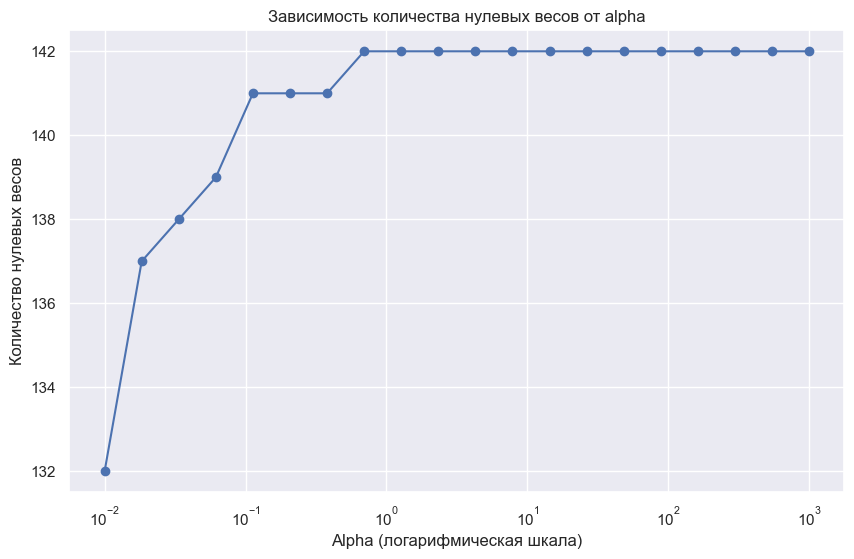

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(count_of_zs['alpha'], count_of_zs['count'], marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('Количество нулевых весов')
plt.title('Зависимость количества нулевых весов от alpha')
plt.grid(True)
plt.show()

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 15.** Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими редкими парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

**Вопрос**: Почему такой признак потенциально полезный? Почему линейная модель не может самостоятельно "вытащить" эту информацию, ведь у нее в распоряжении есть признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка"?

In [55]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from collections import Counter

data['grid_pair'] = list(zip(data['pickup_grid'], data['dropoff_grid']))

pair_counts = Counter(data['grid_pair'])
top_100_pairs = dict(pair_counts.most_common(100))

# Функция для кодирования пар
def encode_pair(pair):
    return top_100_pairs.get(pair, -1)  # Возвращаем индекс пары или -1 для редких

# Создадим новый категориальный признак на основе частотных пар
data['pair_category'] = data['grid_pair'].apply(encode_pair)

# Удалите вспомогательный столбец "grid_pair", если он больше не нужен
data = data.drop(columns=['grid_pair'])
# Посмотрим на результат
print(data[['pickup_grid', 'dropoff_grid', 'pair_category']].head())

   pickup_grid  dropoff_grid  pair_category
0           33            33          87383
1           25            16          31373
3           16            16          53475
4           41            33          11187
5           25            24          65491


Переобучите модель на новых даннных и посчитайте качество на тестовой выборке

In [69]:
#╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
x_train, x_test, y_train, y_test = train_test_split(data, data['log_trip_duration'], test_size=0.3, random_state=42)

# Определяем признаки и таргет
features = ['hour',	'month', 'day_of_week', 'day_of_year', 'haversine', 
            'log_haversine', 'traffic_jam',	'airport',	'pickup_grid',	'dropoff_grid', "pair_category"]
target = 'log_trip_duration'

X_train = x_train[features]
y_train = x_train[target]
X_test = x_test[features]
y_test = x_test[target]

# Разделяем числовые и категориальные признаки
numeric_features = ['day_of_year', 'haversine',	'log_haversine', "pair_category"]
categorical_features = [f for f in features if f not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(best_alpha1))
])

# Обучаем модель на train
pipeline.fit(X_train, y_train)

# Предсказываем на test и оцениваем (MSE, так как таргет — log_trip_duration)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse}")

# RMSLE (корень из MSE, так как таргет логарифмирован)
rmsle = np.sqrt(mse)
print(f"RMSLE на тестовой выборке: {rmsle}")



MSE на тестовой выборке: 0.18588893385999986
RMSLE на тестовой выборке: 0.4311483896061771
